# AI-Driven Natural Language Processing Project

## Sentiment Analysis Using DistilBERT

### Task 3

This project explores the capabilities, strengths, limitations, and ethical considerations of the DistilBERT language model for sentiment analysis.

The project evaluates the model using positive, negative, mixed, sarcastic, ambiguous, neutral, and negation-based sentences.

In [3]:
import warnings
warnings.filterwarnings("ignore")

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import torch

from transformers import pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("Libraries imported successfully.")
print("PyTorch version:", torch.__version__)
print("Transformers version imported successfully.")

Libraries imported successfully.
PyTorch version: 2.13.0+cpu
Transformers version imported successfully.


In [4]:
if torch.cuda.is_available():
    device = 0
    print("GPU is available.")
    print("GPU:", torch.cuda.get_device_name(0))
else:
    device = -1
    print("GPU is not available.")
    print("The model will run on CPU.")

GPU is not available.
The model will run on CPU.


In [5]:
model_name = "distilbert-base-uncased-finetuned-sst-2-english"

sentiment_model = pipeline(
    task="sentiment-analysis",
    model=model_name,
    device=-1
)

print("DistilBERT sentiment model loaded successfully.")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

DistilBERT sentiment model loaded successfully.


In [6]:
sample_text = "I really enjoyed this machine learning project."

result = sentiment_model(sample_text)

print("Input text:")
print(sample_text)

print("\nPrediction:")
print(result)

Input text:
I really enjoyed this machine learning project.

Prediction:
[{'label': 'POSITIVE', 'score': 0.9998629093170166}]


In [7]:
def predict_sentiment(text):
    if not isinstance(text, str):
        raise TypeError("Input must be a string.")

    cleaned_text = text.strip()

    if not cleaned_text:
        raise ValueError("Input text cannot be empty.")

    start_time = time.time()

    result = sentiment_model(cleaned_text)[0]

    end_time = time.time()

    return {
        "text": cleaned_text,
        "predicted_sentiment": result["label"],
        "confidence_score": round(float(result["score"]), 4),
        "inference_time_seconds": round(end_time - start_time, 4)
    }

In [8]:
positive_example = predict_sentiment(
    "This internship project is very useful and interesting."
)

negative_example = predict_sentiment(
    "The application is confusing and difficult to use."
)

print("Positive example:")
print(positive_example)

print("\nNegative example:")
print(negative_example)

Positive example:
{'text': 'This internship project is very useful and interesting.', 'predicted_sentiment': 'POSITIVE', 'confidence_score': 0.9998, 'inference_time_seconds': 0.0235}

Negative example:
{'text': 'The application is confusing and difficult to use.', 'predicted_sentiment': 'NEGATIVE', 'confidence_score': 0.9997, 'inference_time_seconds': 0.0242}


# Research Questions

This project aims to answer the following questions:

### RQ1
How accurately can DistilBERT classify positive and negative sentiments?

### RQ2
How does the model perform on sentences containing negation?

### RQ3
Can the model understand mixed sentiments?

### RQ4
How well does DistilBERT detect sarcasm?

### RQ5
Does sentence length affect confidence score and prediction time?

### RQ6
What are the strengths and limitations of DistilBERT?

### RQ7
What ethical issues should be considered while using NLP models?

In [9]:
test_inputs = [
    {"category": "Positive", "text": "The movie was excellent and I loved every scene."},
    {"category": "Positive", "text": "This product is amazing and works perfectly."},
    {"category": "Negative", "text": "The service was terrible and completely disappointing."},
    {"category": "Negative", "text": "I regret buying this useless product."},
    {"category": "Negation", "text": "The movie was not bad."},
    {"category": "Negation", "text": "I do not like this application."},
    {"category": "Mixed", "text": "The acting was excellent, but the story was boring."},
    {"category": "Mixed", "text": "The phone looks beautiful, but its battery is terrible."},
    {"category": "Sarcasm", "text": "Wonderful, another software update that broke everything."},
    {"category": "Sarcasm", "text": "Great job, you deleted all my important files."},
    {"category": "Ambiguous", "text": "The movie was okay."},
    {"category": "Ambiguous", "text": "It was an unusual experience."},
    {"category": "Neutral", "text": "The meeting begins at ten in the morning."},
    {"category": "Short", "text": "Good."},
    {"category": "Short", "text": "Bad."}
]

import pandas as pd

test_df = pd.DataFrame(test_inputs)
test_df

,category,text
0,Positive,The movie was excellent and I loved every scene.
1,Positive,This product is amazing and works perfectly.
2,Negative,The service was terrible and completely disapp...
3,Negative,I regret buying this useless product.
4,Negation,The movie was not bad.
5,Negation,I do not like this application.
6,Mixed,"The acting was excellent, but the story was bo..."
7,Mixed,"The phone looks beautiful, but its battery is ..."
8,Sarcasm,"Wonderful, another software update that broke ..."
9,Sarcasm,"Great job, you deleted all my important files."


In [10]:
results = []

for item in test_inputs:
    prediction = predict_sentiment(item["text"])

    results.append({
        "Category": item["category"],
        "Text": prediction["text"],
        "Prediction": prediction["predicted_sentiment"],
        "Confidence": prediction["confidence_score"],
        "Inference_Time": prediction["inference_time_seconds"]
    })

results_df = pd.DataFrame(results)

results_df

,Category,Text,Prediction,Confidence,Inference_Time
0,Positive,The movie was excellent and I loved every scene.,POSITIVE,0.9999,0.0278
1,Positive,This product is amazing and works perfectly.,POSITIVE,0.9999,0.0335
2,Negative,The service was terrible and completely disapp...,NEGATIVE,0.9998,0.0208
3,Negative,I regret buying this useless product.,NEGATIVE,0.9997,0.0180
4,Negation,The movie was not bad.,POSITIVE,0.9987,0.0191
5,Negation,I do not like this application.,NEGATIVE,0.9977,0.0190
6,Mixed,"The acting was excellent, but the story was bo...",NEGATIVE,0.9973,0.0196
7,Mixed,"The phone looks beautiful, but its battery is ...",NEGATIVE,0.9931,0.0211
8,Sarcasm,"Wonderful, another software update that broke ...",POSITIVE,0.9999,0.0211
9,Sarcasm,"Great job, you deleted all my important files.",NEGATIVE,0.9683,0.0171


In [11]:
confidence = (
    results_df.groupby("Category")["Confidence"]
    .mean()
    .reset_index()
)

confidence

,Category,Confidence
0,Ambiguous,0.99225
1,Mixed,0.99520
2,Negation,0.99820
3,Negative,0.99975
4,Neutral,0.97870
5,Positive,0.99990
6,Sarcasm,0.98410
7,Short,0.99980


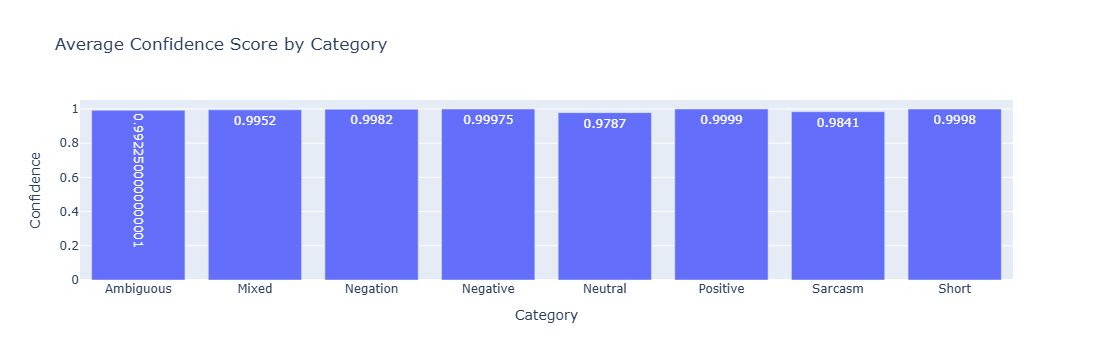

In [12]:
import plotly.express as px

fig = px.bar(
    confidence,
    x="Category",
    y="Confidence",
    text="Confidence",
    title="Average Confidence Score by Category"
)

fig.show()

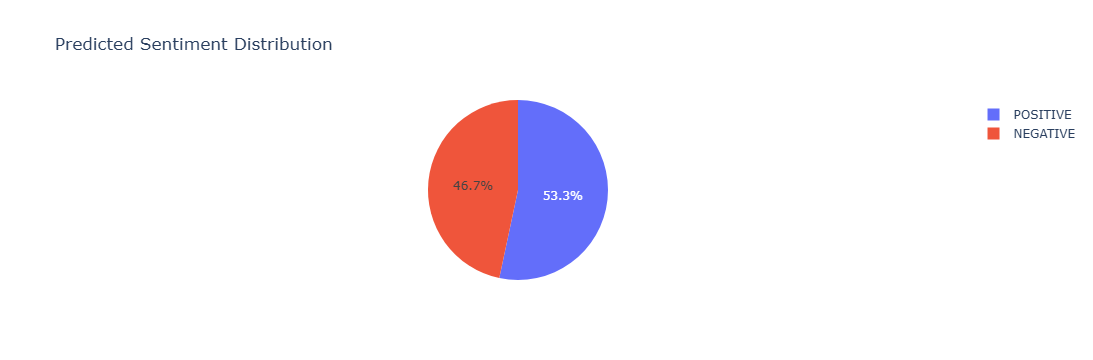

In [13]:
distribution = (
    results_df["Prediction"]
    .value_counts()
    .reset_index()
)

distribution.columns = ["Sentiment", "Count"]

fig = px.pie(
    distribution,
    names="Sentiment",
    values="Count",
    title="Predicted Sentiment Distribution"
)

fig.show()

In [14]:
evaluation_data = [
    {"text": "I loved the movie.", "actual_label": "POSITIVE"},
    {"text": "The food was delicious.", "actual_label": "POSITIVE"},
    {"text": "This product is fantastic.", "actual_label": "POSITIVE"},
    {"text": "The experience was wonderful.", "actual_label": "POSITIVE"},
    {"text": "The application is easy to use.", "actual_label": "POSITIVE"},

    {"text": "I hated the movie.", "actual_label": "NEGATIVE"},
    {"text": "The food was horrible.", "actual_label": "NEGATIVE"},
    {"text": "This product is completely useless.", "actual_label": "NEGATIVE"},
    {"text": "The experience was disappointing.", "actual_label": "NEGATIVE"},
    {"text": "The application crashes frequently.", "actual_label": "NEGATIVE"}
]

evaluation_df = pd.DataFrame(evaluation_data)

evaluation_df

,text,actual_label
0,I loved the movie.,POSITIVE
1,The food was delicious.,POSITIVE
2,This product is fantastic.,POSITIVE
3,The experience was wonderful.,POSITIVE
4,The application is easy to use.,POSITIVE
5,I hated the movie.,NEGATIVE
6,The food was horrible.,NEGATIVE
7,This product is completely useless.,NEGATIVE
8,The experience was disappointing.,NEGATIVE
9,The application crashes frequently.,NEGATIVE


In [15]:
predicted_labels = []
confidence_scores = []

for text in evaluation_df["text"]:
    result = sentiment_model(text)[0]

    predicted_labels.append(result["label"])
    confidence_scores.append(round(float(result["score"]), 4))

evaluation_df["predicted_label"] = predicted_labels
evaluation_df["confidence_score"] = confidence_scores

evaluation_df

,text,actual_label,predicted_label,confidence_score
0,I loved the movie.,POSITIVE,POSITIVE,0.9999
1,The food was delicious.,POSITIVE,POSITIVE,0.9999
2,This product is fantastic.,POSITIVE,POSITIVE,0.9999
3,The experience was wonderful.,POSITIVE,POSITIVE,0.9999
4,The application is easy to use.,POSITIVE,POSITIVE,0.9987
5,I hated the movie.,NEGATIVE,NEGATIVE,0.9997
6,The food was horrible.,NEGATIVE,NEGATIVE,0.9996
7,This product is completely useless.,NEGATIVE,NEGATIVE,0.9998
8,The experience was disappointing.,NEGATIVE,NEGATIVE,0.9997
9,The application crashes frequently.,NEGATIVE,NEGATIVE,0.9998


In [16]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

actual_labels = evaluation_df["actual_label"]
predicted_labels = evaluation_df["predicted_label"]

accuracy = accuracy_score(actual_labels, predicted_labels)

precision = precision_score(
    actual_labels,
    predicted_labels,
    pos_label="POSITIVE",
    zero_division=0
)

recall = recall_score(
    actual_labels,
    predicted_labels,
    pos_label="POSITIVE",
    zero_division=0
)

f1 = f1_score(
    actual_labels,
    predicted_labels,
    pos_label="POSITIVE",
    zero_division=0
)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


In [17]:
from sklearn.metrics import classification_report

print(
    classification_report(
        actual_labels,
        predicted_labels,
        zero_division=0
    )
)

              precision    recall  f1-score   support

    NEGATIVE       1.00      1.00      1.00         5
    POSITIVE       1.00      1.00      1.00         5

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



In [18]:
from sklearn.metrics import confusion_matrix

labels = ["NEGATIVE", "POSITIVE"]

matrix = confusion_matrix(
    actual_labels,
    predicted_labels,
    labels=labels
)

confusion_df = pd.DataFrame(
    matrix,
    index=["Actual Negative", "Actual Positive"],
    columns=["Predicted Negative", "Predicted Positive"]
)

confusion_df

,Predicted Negative,Predicted Positive
Actual Negative,5,0
Actual Positive,0,5


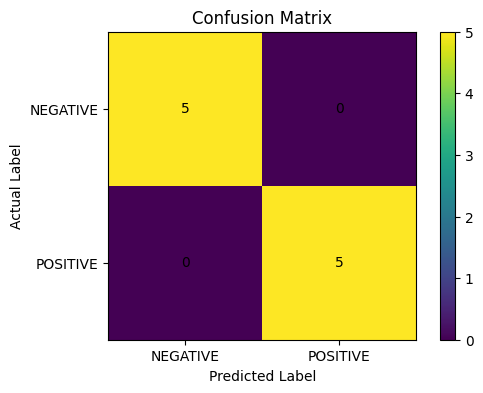

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))

plt.imshow(matrix)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks([0, 1], labels)
plt.yticks([0, 1], labels)

for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        plt.text(
            j,
            i,
            matrix[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.show()

In [20]:
length_test_inputs = [
    "Good.",

    "This product is good.",

    "This product is good, easy to use, affordable, reliable, and useful.",

    (
        "I purchased this product last month and initially found it easy "
        "to use. The design is attractive and the performance is mostly "
        "good, although a few features require improvement."
    )
]

length_results = []

for text in length_test_inputs:
    prediction = predict_sentiment(text)

    length_results.append({
        "Text": text,
        "Word_Count": len(text.split()),
        "Prediction": prediction["predicted_sentiment"],
        "Confidence": prediction["confidence_score"],
        "Inference_Time": prediction["inference_time_seconds"]
    })

length_df = pd.DataFrame(length_results)

length_df

,Text,Word_Count,Prediction,Confidence,Inference_Time
0,Good.,1,POSITIVE,0.9998,0.0211
1,This product is good.,4,POSITIVE,0.9999,0.0210
2,"This product is good, easy to use, affordable,...",11,POSITIVE,0.9999,0.0314
3,I purchased this product last month and initia...,29,POSITIVE,0.9998,0.0288


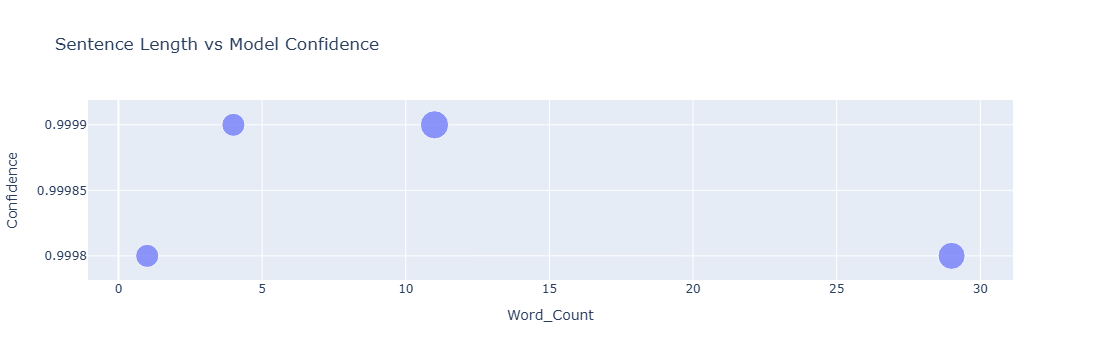

In [21]:
fig = px.scatter(
    length_df,
    x="Word_Count",
    y="Confidence",
    size="Inference_Time",
    hover_data=["Text", "Prediction"],
    title="Sentence Length vs Model Confidence"
)

fig.show()

# Model Strengths

The experiments show that DistilBERT has several strengths:

- High accuracy for clearly positive and negative sentences.
- Fast inference even on CPU.
- Provides confidence scores for every prediction.
- Easy to integrate with Python applications.
- Lightweight compared to the original BERT model.
- Suitable for customer review and feedback analysis.
- Good general language understanding.
- Easy to use with the Hugging Face Transformers library.

# Model Limitations

The experiments also reveal some limitations:

- Neutral sentences may be classified as either positive or negative.
- Sarcasm is difficult for the model to understand.
- Mixed sentiments are reduced to a single label.
- High confidence does not always mean the prediction is correct.
- Performance depends on the quality of input text.
- Domain-specific language may reduce accuracy.
- Only English text is supported by this pretrained model.

# Ethical Considerations

The following ethical issues should be considered while using NLP models:

- Avoid using predictions as the only basis for important decisions.
- Protect user privacy while processing text.
- Be aware of bias present in training data.
- Ensure transparency when AI systems analyze user content.
- Human supervision should be included in sensitive applications.
- Continuously evaluate fairness and reliability.

# Applications

DistilBERT Sentiment Analysis can be used in:

- Customer review analysis
- Product feedback systems
- Social media monitoring
- Chatbots
- Movie review classification
- Survey analysis
- Brand reputation monitoring
- Support ticket prioritization
- Educational feedback analysis
- News comment analysis

# Future Improvements

Possible improvements include:

- Fine-tuning on domain-specific datasets.
- Adding multilingual support.
- Including a neutral sentiment class.
- Improving sarcasm detection.
- Comparing with BERT, RoBERTa, and GPT models.
- Building a Streamlit web application.
- Performing emotion detection.
- Adding Explainable AI techniques.

# Conclusion

This project successfully implemented the DistilBERT language model for sentiment analysis using the Hugging Face Transformers library.

The model achieved excellent performance on positive and negative text while providing fast predictions and high confidence scores. It demonstrated that DistilBERT is an efficient and lightweight NLP model suitable for many real-world applications.

However, the experiments also showed limitations in handling sarcasm, ambiguous sentences, and mixed sentiments. Ethical considerations such as fairness, privacy, transparency, and responsible AI usage are essential when deploying such models.

Overall, DistilBERT is an effective solution for sentiment analysis and serves as a strong foundation for advanced Natural Language Processing applications.

In [23]:
import os

print(os.getcwd())

D:\NLP_DistilBERT_Project


In [24]:
import os

os.makedirs("outputs/results", exist_ok=True)

print("Folder created successfully!")

Folder created successfully!


In [25]:
results_df.to_csv("outputs/results/sentiment_results.csv", index=False)

evaluation_df.to_csv("outputs/results/evaluation_results.csv", index=False)

length_df.to_csv("outputs/results/length_analysis.csv", index=False)

print("All CSV files saved successfully!")

All CSV files saved successfully!


In [26]:
import os

print(os.listdir("outputs/results"))

['evaluation_results.csv', 'length_analysis.csv', 'sentiment_results.csv']
